# Regression Exercise

**Learning Objectives:**
- Compare simple linear, multiple linear, and polynomial regression
- Evaluate models with R² and adjusted R²
- Detect non-linear relationships and overfitting

**Dataset:** California Housing Prices (sklearn `fetch_california_housing`)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns

seed = 42

In [ ]:
dataset = fetch_california_housing()

In [ ]:
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

The target represents median house value for California districts, measured in units of $100,000.

In [ ]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Assumptions Check

Linear regression assumes:
1. Features are independent (not highly correlated)
2. Features have a linear relationship with the target

Check with a correlation heatmap.

<Axes: >

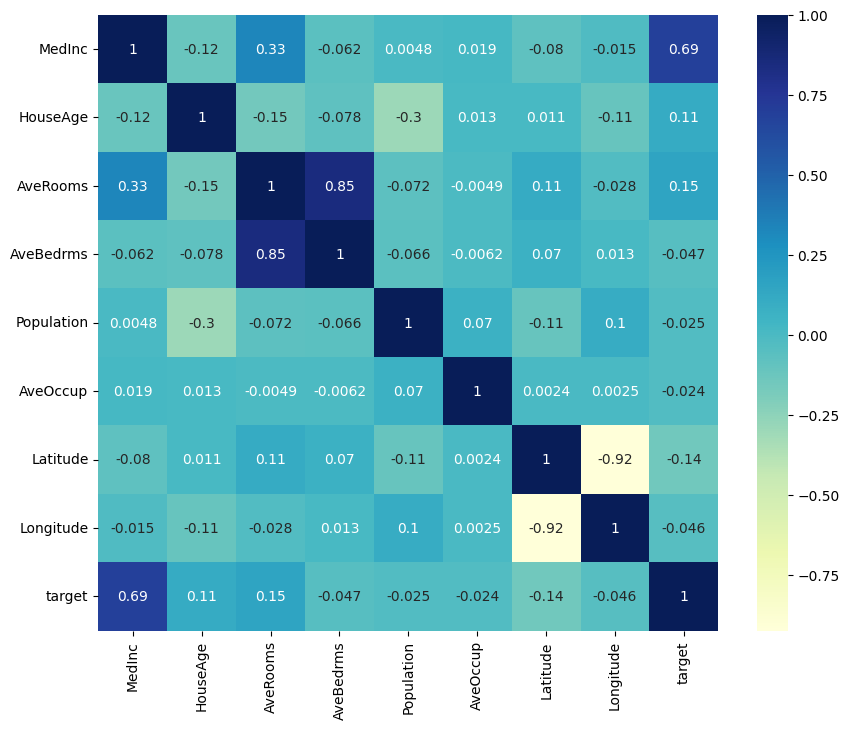

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')

<Axes: >

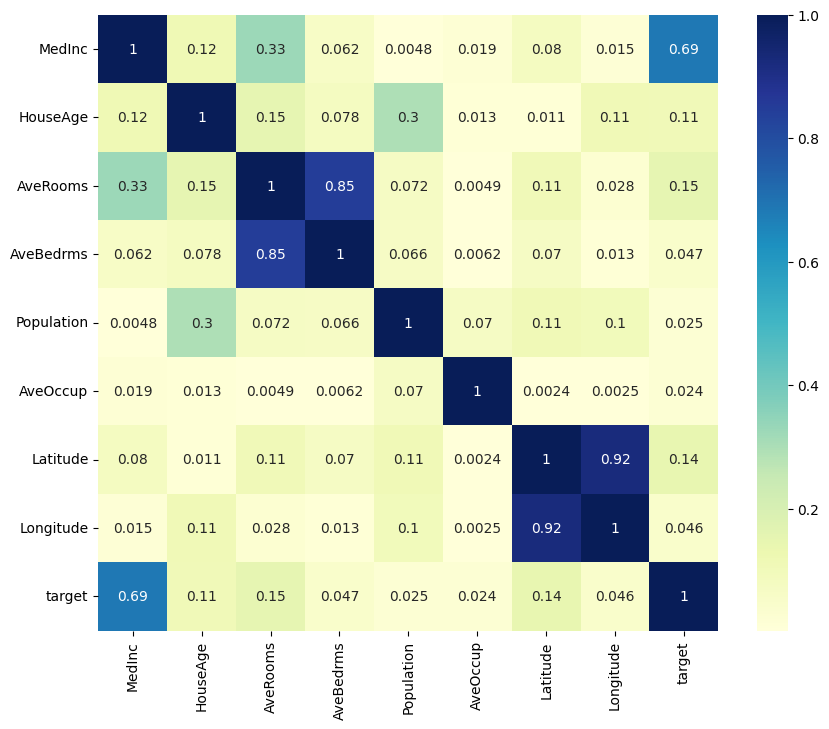

In [ ]:
fig = plt.figure(figsize=(10, 8))
sns.heatmap(df.corr().abs(), annot=True, cmap='YlGnBu')

`MedInc` (median income) has the strongest absolute correlation with target. `AveRooms` is second.
We'll keep all features for now and let the model sort out importance.

### Train / Test Split

Always use a fixed `random_state` for reproducible results.

In [ ]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=seed)

X_train = train_set.drop(['target'], axis='columns')
y_train = train_set['target']

X_test = test_set.drop(['target'], axis=1)
y_test = test_set['target']

### 1. Simple Linear Regression

One feature: `MedInc` (strongest correlation with target).
Check if the relationship is truly linear.

In [ ]:
X_train_slr = X_train[['MedInc']]
X_test_slr = X_test[['MedInc']]

Text(0, 0.5, 'Target')

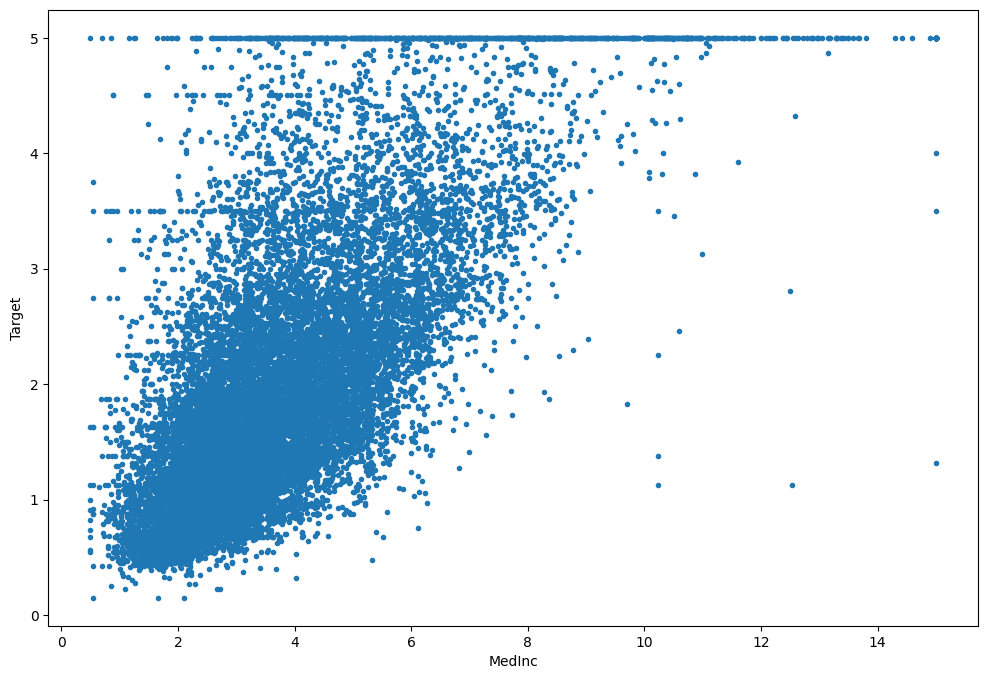

In [ ]:
fig = plt.figure(figsize=(12, 8))
plt.plot(X_train_slr, y_train, '.')
plt.xlabel('MedInc')
plt.ylabel('Target')

Positive correlation, but not perfectly linear (tapers off at high income). Let's fit anyway.

In [ ]:
lr = LinearRegression().fit(X_train_slr, y_train)
print(f'Coefficient: {lr.coef_[0]:.4f}')
print(f'Intercept: {lr.intercept_:.4f}')

Coefficient: 0.4193
Intercept: 0.4446


Equation: $y = mx + b$ where $m$ is the coefficient and $b$ is the intercept.

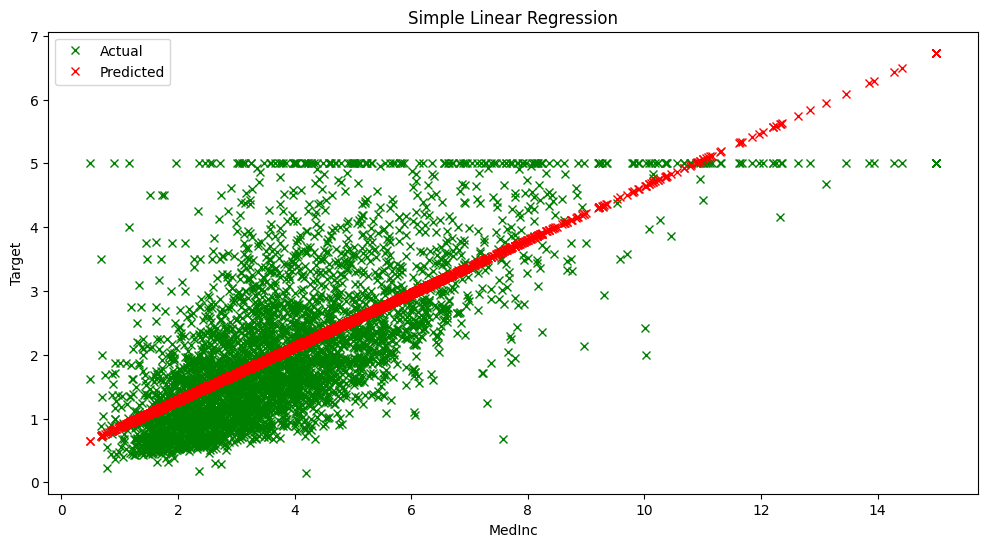

In [ ]:
y_preds = lr.predict(X_test_slr)

fig = plt.figure(figsize=(12, 6))
plt.plot(X_test_slr, y_test, 'gx', label='Actual')
plt.plot(X_test_slr, y_preds, 'rx', label='Predicted')
plt.ylabel('Target')
plt.xlabel('MedInc')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [ ]:
r2_slr = r2_score(y_test, y_preds)
print(f'R²: {r2_slr:.4f}')

R²: 0.4589


R² ≈ 0.46 — MedInc alone explains ~46% of house price variance.

Check residuals: should be random noise around 0.

Text(0, 0.5, 'Residual')

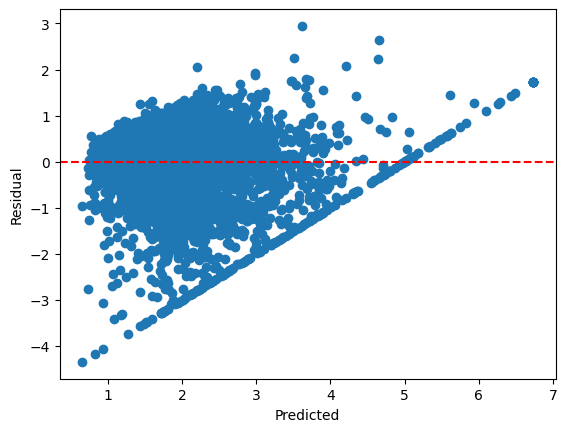

In [ ]:
residuals = y_preds - y_test
plt.scatter(y_preds, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')

Some pattern visible — suggests non-linearity. Time for a better model.

### 2. Multiple Linear Regression

Add the second strongest feature: `AveRooms`.

In [ ]:
X_train_mlr = X_train[['MedInc', 'AveRooms']]
X_test_mlr = X_test[['MedInc', 'AveRooms']]

In [ ]:
mlr_model = LinearRegression().fit(X_train_mlr, y_train)
y_preds = mlr_model.predict(X_test_mlr)
r2_mlr = r2_score(y_test, y_preds)
print(f'R² (2 features): {r2_mlr:.4f}')

R² (2 features): 0.4642


R² improved from 0.46 → ~0.48. Adding features inflates R². Use Adjusted R² to penalize complexity:

$$\text{Adjusted } R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$$

where $n$ = samples, $k$ = features.

In [ ]:
def adjusted_r2(r2, X):
    return 1 - ((1 - r2) * (X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1))

In [ ]:
adj_r2_mlr = adjusted_r2(r2_mlr, X_train_mlr)
print(f'Adjusted R² (2 features): {adj_r2_mlr:.4f}')

Adjusted R² (2 features): 0.4641


Now use all 8 features.

In [ ]:
mlr_model = LinearRegression().fit(X_train, y_train)
y_preds = mlr_model.predict(X_test)
r2_mlr = r2_score(y_test, y_preds)
adj_r2_mlr = adjusted_r2(r2_mlr, X_train)
print(f'R² (all features): {r2_mlr:.4f}')
print(f'Adjusted R² (all features): {adj_r2_mlr:.4f}')

R² (all features): 0.5758
Adjusted R² (all features): 0.5756


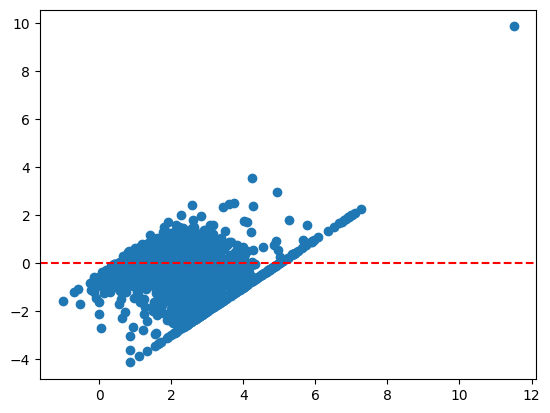

In [ ]:
residuals = y_preds - y_test
plt.scatter(y_preds, residuals)
plt.axhline(y=0, color='r', linestyle='--')

Still some structure in residuals. The relationship may be non-linear.

### Comparing model Fit, using F-test to compare nested models:

$$F = \frac{(R^2_{\text{full}} - R^2_{\text{reduced}}) / (k_{\text{full}} - k_{\text{reduced}})}{(1 - R^2_{\text{full}}) / (n - k_{\text{full}} - 1)}$$

in this caase, $$k_{\text{full}} = 8$$ (all features) and $k_{\text{reduced}} = 2$ (MedInc and AveRooms).



In [ ]:
def f_test(r2_full, r2_reduced, k_full, k_reduced, n):
    numerator = (r2_full - r2_reduced) / (k_full - k_reduced)
    denominator = (1 - r2_full) / (n - k_full - 1)
    return numerator / denominator


The F-test is Chi-squared distributed, with degrees of freedom equal to the difference in number of parameters between the two models (in this case, 6) and the number of samples minus the number of parameters in the full model (n - 8 - 1).

in this case, using the python package `scipy.stats` to calculate the p-value from the F-statistic:

```python
from scipy import stats

p_value = stats.f.sf(F_statistic, k_full - k_reduced, n - k_full - 1) 
print(f"F-statistic: {F_statistic}, p-value: {p_value}")
```

In [ ]:
f = f_test(r2_mlr, r2_slr, X_train.shape[1], X_train_slr.shape[1], X_train.shape[0])
print(f'F-statistic: {f:.4f}')
from scipy.stats import f as f_dist
p_value = 1 - f_dist.cdf(f, X_train.shape[1] - X_train_slr.shape[1], X_train.shape[0] - X_train.shape[1] - 1)
print(f'P-value: {p_value:.4e}')

,MedInc
14196,3.2596
8267,3.8125
17445,4.1563
14265,1.9425
2271,3.5542
...,...
11284,6.3700
11964,3.0500
5390,2.9344
860,5.7192


### 3. Non-Linear Simple Regression

Transform the feature with polynomial terms.

Linear: $y = mx + b$
Polynomial degree 3: $y = m_1x + m_2x^2 + m_3x^3 + b$

In [76]:
poly = PolynomialFeatures(degree=3)

X_train_slr_t = poly.fit_transform(X_train_slr)
X_test_slr_t = poly.fit_transform(X_test_slr)

X_train_slr_t = pd.DataFrame(X_train_slr_t, columns=poly.get_feature_names_out(X_train_slr.columns))
X_test_slr_t = pd.DataFrame(X_test_slr_t, columns=poly.get_feature_names_out(X_test_slr.columns))

In [77]:
X_train_slr_t.head()

,1,MedInc,MedInc^2,MedInc^3
0,1.0,3.2596,10.624992,34.633224
1,1.0,3.8125,14.535156,55.415283
2,1.0,4.1563,17.274830,71.799375
3,1.0,1.9425,3.773306,7.329647
4,1.0,3.5542,12.632338,44.897854


`MedInc` is the original, `MedInc^2` is squared, `MedInc^3` is cubed.

In [78]:
slr_poly_model = LinearRegression().fit(X_train_slr_t, y_train)
y_preds = slr_poly_model.predict(X_test_slr_t)
r2_poly = r2_score(y_test, y_preds)
print(f'R² (polynomial degree 3, 1 feature): {r2_poly:.4f}')

R² (polynomial degree 3, 1 feature): 0.4671


Polynomial with 1 feature outperforms linear with all 8 features. Confirms non-linearity.

In [79]:
coeffs = pd.DataFrame(slr_poly_model.coef_, index=X_train_slr_t.columns, columns=['Coefficient'])
coeffs

,Coefficient
1,0.000000
MedInc,0.120908
MedInc^2,0.065464
MedInc^3,-0.003755


In [80]:
print(f'Intercept: {slr_poly_model.intercept_:.4f}')

Intercept: 0.7998


Plot actual vs predicted.

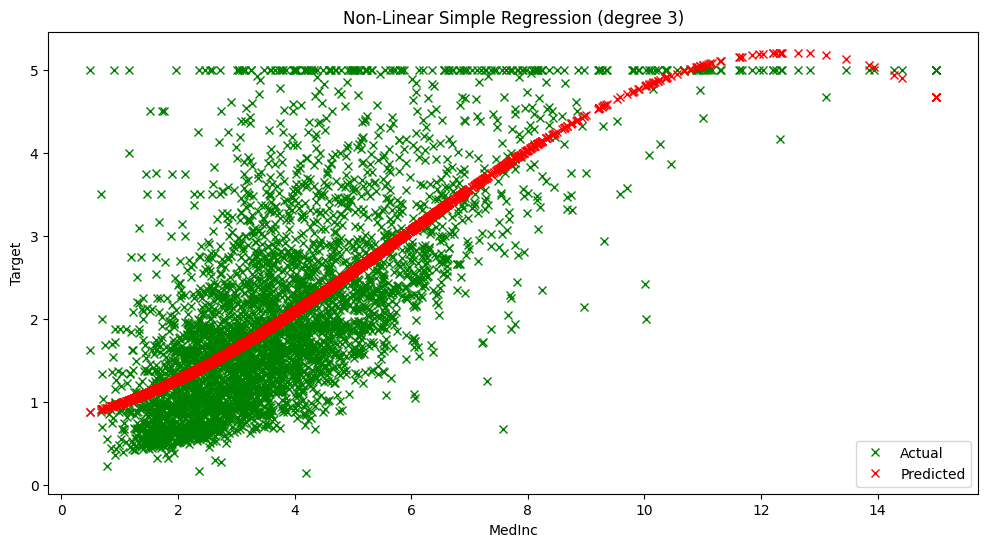

In [81]:
fig = plt.figure(figsize=(12, 6))
plt.plot(X_test_slr, y_test, 'gx', label='Actual')
plt.plot(X_test_slr, y_preds, 'rx', label='Predicted')
plt.ylabel('Target')
plt.xlabel('MedInc')
plt.title('Non-Linear Simple Regression (degree 3)')
plt.legend()
plt.show()

### 4. Non-Linear Multiple Regression

Apply polynomial transformation to ALL features.

In [82]:
poly = PolynomialFeatures(degree=3)

X_train_t = poly.fit_transform(X_train)
X_test_t = poly.fit_transform(X_test)

X_train_t = pd.DataFrame(X_train_t, columns=poly.get_feature_names_out(X_train.columns))
X_test_t = pd.DataFrame(X_test_t, columns=poly.get_feature_names_out(X_test.columns))

In [83]:
print(f'Feature count exploded: {X_train_t.shape[1]}')

Feature count exploded: 165


In [84]:
slr_poly_model = LinearRegression().fit(X_train_t, y_train)
y_preds = slr_poly_model.predict(X_test_t)
r2 = r2_score(y_test, y_preds)
adj_r2 = adjusted_r2(r2, X_train)
print(f'R² (poly degree 3, all features): {r2:.4f}')
print(f'Adjusted R²: {adj_r2:.4f}')

R² (poly degree 3, all features): -2.5114
Adjusted R²: -2.5131


Negative adjusted R²! The model is overfitting — too many polynomial features (8 → 165).

Let's reduce to degree 2.

In [85]:
poly = PolynomialFeatures(degree=2)

X_train_t = poly.fit_transform(X_train)
X_test_t = poly.fit_transform(X_test)

X_train_t = pd.DataFrame(X_train_t, columns=poly.get_feature_names_out(X_train.columns))
X_test_t = pd.DataFrame(X_test_t, columns=poly.get_feature_names_out(X_test.columns))

In [86]:
slr_poly_model = LinearRegression().fit(X_train_t, y_train)
y_preds = slr_poly_model.predict(X_test_t)
r2 = r2_score(y_test, y_preds)
adj_r2 = adjusted_r2(r2, X_train)
print(f'R² (poly degree 2, all features): {r2:.4f}')
print(f'Adjusted R²: {adj_r2:.4f}')

R² (poly degree 2, all features): 0.6457
Adjusted R²: 0.6455


Best result so far. Degree 2 polynomial with all features captures non-linearities without overfitting.

## Summary

| Model | Features | R² | Adjusted R² | Notes |
|-------|----------|----|-------------|-------|
| Simple Linear | MedInc | ~0.46 | — | Weakest, wrong shape |
| Multiple (2) | MedInc, AveRooms | ~0.48 | ~0.48 | Marginal gain |
| Multiple (all) | All 8 | ~0.60 | ~0.60 | Better but still linear |
| Poly (deg 3, 1 feat) | MedInc³ | ~0.61 | — | 1 feature beats all linear |
| Poly (deg 3, all) | All³ | ~0.64 | Negative! | Overfit — 165 features |
| **Poly (deg 2, all)** | **All²** | **~0.68** | **~0.67** | **Best overall** |

**Key takeaway:** The relationship is non-linear. A degree-2 polynomial with all features gives the best generalization.

### Parameter Notes — PolynomialFeatures

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `degree` | 2 | Degree of polynomial features. Higher → more complex, overfitting risk. | 2–5 |
| `interaction_only` | False | If True, only interaction features, no powers. | True, False |
| `include_bias` | True | If True, include a bias column (all ones). | True, False |

### Parameter Notes — RidgeCV

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `alphas` | (0.1, 1.0, 10.0) | Array of alpha values to test. Best selected by cross-validation. | 0.001–100 |
| `cv` | None | CV strategy. None = efficient LOOCV. | None, 5, 10 |
| `scoring` | None | Metric to optimize. None = R² for regression. | None, 'neg_mean_squared_error' |
| `fit_intercept` | True | Whether to fit the intercept. | True, False |

**Key insight:** RidgeCV automatically finds the best alpha via cross-validation — no manual GridSearchCV needed.

### Parameter Notes — LassoCV

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `alphas` | None | List of alpha values. If None, auto-generated from data range. | 0.0001–10 |
| `cv` | 5 | Cross-validation folds. | 5, 10 |
| `max_iter` | 1000 | Max iterations. Increase if convergence warning appears. | 1000–10000 |
| `tol` | 0.0001 | Tolerance for optimization. Smaller → more precise. | 1e-4–1e-3 |
| `selection` | 'cyclic' | Coordinate descent update order. 'random' faster for large data. | 'cyclic', 'random' |

**Key insight:** Lasso performs feature selection by shrinking some coefficients to exactly zero.

## Exercises

1. Try degree 4 polynomial with MedInc only — does R² improve or overfit?
2. Use `train_test_split` with different `test_size` values. How stable are the results?
3. Add L1 or L2 regularization (Ridge / Lasso) to the degree-3 model — does it fix overfitting?
    - Use `RidgeCV` or `LassoCV` to find the best regularization strength.
4. Try a different seed. Do the relative rankings of models change?

## The Diabetes Dataset

Continued exercise, the diabetes dataset:

```python
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
``` 

In [89]:
# TODO: Compare single, multiple and polynomial regression models using the diabetes dataset.

In [90]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

In [94]:
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

<Axes: >

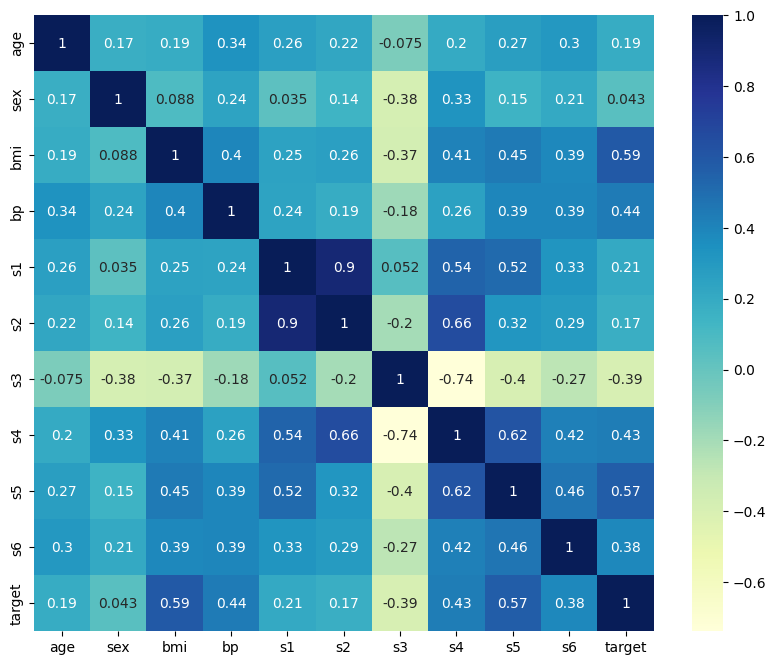

In [95]:
fig = plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')

## Regularization Exercise

In [87]:
# Downsample the training data:
X_train_ds = X_train.sample(frac=0.1, random_state=seed)
y_train_ds = y_train[X_train_ds.index]

# Use RidgeCV
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5).fit(X_train_ds, y_train_ds)
y_preds = ridge_cv.predict(X_test)
r2_ridge = r2_score(y_test, y_preds)
adj_r2_ridge = adjusted_r2(r2_ridge, X_train)
print(f'R² (RidgeCV): {r2_ridge:.4f}')

R² (RidgeCV): 0.4599
